# Preprocessing Workflow for reverberation removal

This notebook loads the same DICOM acquisition and hardcoded ROI used in the reverberation report, applies different filters and calculations to remove reverberations.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pydicom
from skimage.morphology import white_tophat
import napari

from napari_convpaint import ConvpaintWidget, ConvpaintModel

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'gray'

In [ ]:
# Same source and selection as reverberation_artifact_report.ipynb
repository_root = Path('..').resolve()
dicom_input_dir = repository_root / 'data' / 'ultrasound' / 'raices reales' / '1'
dicom_files = sorted(dicom_input_dir.glob('*.dcm'))

if len(dicom_files) == 0:
    raise FileNotFoundError(f'No DICOM files found in: {dicom_input_dir}')

selected_dicom_index = 0
selected_dicom_path = dicom_files[selected_dicom_index]
dataset = pydicom.dcmread(selected_dicom_path)
raw = dataset.pixel_array

if raw.ndim == 4:
    frames = raw[..., 0]
elif raw.ndim == 3:
    frames = raw
elif raw.ndim == 2:
    frames = raw[np.newaxis, ...]
else:
    raise ValueError(f'Unsupported DICOM pixel array shape: {raw.shape}')

# Same hardcoded ROI from the report
min_x, max_x = 401, 619
min_y, max_y = 116, 689

y0 = max(0, min_y)
y1 = min(frames.shape[1] - 1, max_y)
x0 = max(0, min_x)
x1 = min(frames.shape[2] - 1, max_x)

if y0 > y1 or x0 > x1:
    raise ValueError('Invalid ROI after clipping. Check min/max x/y values.')

roi_mask_2d = np.zeros(frames.shape[1:], dtype=bool)
roi_mask_2d[y0:y1 + 1, x0:x1 + 1] = True
volume = frames[:, y0:y1 + 1, x0:x1 + 1].astype(np.float32)

print(f'Loaded DICOM: {selected_dicom_path}')
print(f'frames shape: {frames.shape}, ROI volume shape: {volume.shape}')

No previous annotations found
Loaded DICOM: C:\Users\corba\Documents\eco-root\data\ultrasound\raices reales\1\001.dcm
frames shape: (189, 768, 1024), ROI volume shape: (189, 574, 219)
Model will be saved at: C:\Users\corba\Documents\eco-root\exploration\models\reverb_convpaint_model.pkl
Annotations will be loaded from: C:\Users\corba\Documents\eco-root\exploration\models\reverb_convpaint_labels.npy


In [4]:
viewer = napari.Viewer(title='Convpaint Labeling - Reverberation ROI')
viewer.add_image(volume, name='volume', colormap='gray')

<Image layer 'volume' at 0x16983eab990>

## 1) Apply white tophat in plane perpendicular to wave propagation

Perpendicular to wave propagation, the reverberances look quite homogeneous, this translates into a rolling ball or white tophat filter being ideal to remove some of the noise.

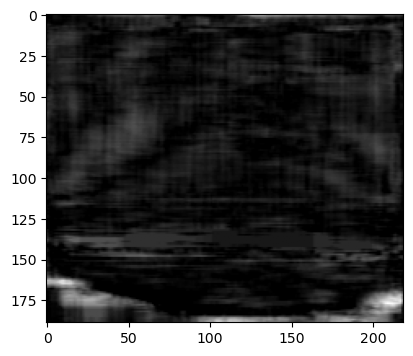

In [ ]:
import matplotlib.pyplot as plt

example_image = np.swapaxes(volume, 0, 1)[0]

footprint = np.ones((10, 60), dtype=bool)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(example_image)
axs[0].set_title("Original Image")
axs[0].axis('off')
axs[1].imshow(white_tophat(example_image, footprint))
axs[1].set_title("White Tophat")
axs[1].axis('off')
plt.show()

We will define a function to apply white tophat to every plane in the direction of wave propagation.

In [ ]:
def process_white_tophat(volume, footprint = np.ones((20, 20), dtype=bool)):
    processed_volume = np.zeros_like(volume)
    processed_volume = np.swapaxes(processed_volume, 0, 1)
    print(processed_volume.shape)
    for n, plane in enumerate(np.swapaxes(volume, 0, 1)):
        processed_volume[n] = white_tophat(plane, footprint)
    
    return np.swapaxes(processed_volume, 0, 1)

In [43]:
from skimage.filters import meijering

def process_with_meijering(volume, sigmas = (1, 2, 3)):
    processed_volume = np.zeros_like(volume)
    processed_volume = np.swapaxes(processed_volume, 0, 1)
    print(processed_volume.shape)
    for n, plane in enumerate(np.swapaxes(volume, 0, 1)):
        processed_volume[n] = meijering(plane, black_ridges=False, sigmas=sigmas)

    return np.swapaxes(processed_volume, 0, 1)

In [25]:
viewer_results = napari.Viewer(title='Convpaint Processing')
viewer_results.add_image(volume, name='volume', colormap='gray')
viewer_results.add_image(processed_volume, name='processed', colormap='gray')

print('Napari results viewer opened.')
print('Layers: roi_frame, convpaint_mask, masked_image (toggle visibility as needed).')

Napari results viewer opened.
Layers: roi_frame, convpaint_mask, masked_image (toggle visibility as needed).


In [33]:
viewer_results = napari.Viewer(title='Convpaint Processing')
viewer_results.add_image(np.swapaxes(volume, 0, 1), name='volume', colormap='gray')
viewer_results.add_image(np.swapaxes(processed_volume, 0, 1), name='processed volume', colormap='gray')

<Image layer 'processed volume' at 0x239fd0b4410>

In [40]:
median_image = np.median(volume, axis=0)
background_subtracted = volume - median_image[...]
background_subtracted = np.clip(background_subtracted, 0, np.inf)

In [65]:
white_tophat_processed = process_white_tophat(background_subtracted, footprint = np.ones((10, 60), dtype=bool))

(574, 189, 219)


In [42]:
viewer_results = napari.Viewer(title='Convpaint Processing')
viewer_results.add_image(volume, name='volume', colormap='gray')
viewer_results.add_image(background_subtracted, name='processed volume', colormap='gray')

<Image layer 'processed volume' at 0x239ff552850>

In [73]:
from skimage.filters import frangi

viewer_results = napari.Viewer(title='Convpaint Processing')
viewer_results.add_image(volume, name='volume', colormap='gray')
viewer_results.add_image(meijering(white_tophat_processed, black_ridges=False, sigmas=(1, 2, 3)), name='processed volume', colormap='gray')

<Image layer 'processed volume' at 0x23ac2a85090>